In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import tensorflow_hub as hub


#Getting data ready (turning images into tensors)

In [2]:
import pandas as pd
labels_csv = pd.read_csv("/Users/lukeopany/Desktop/dog-vision/labels.csv")
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


<Axes: xlabel='breed'>

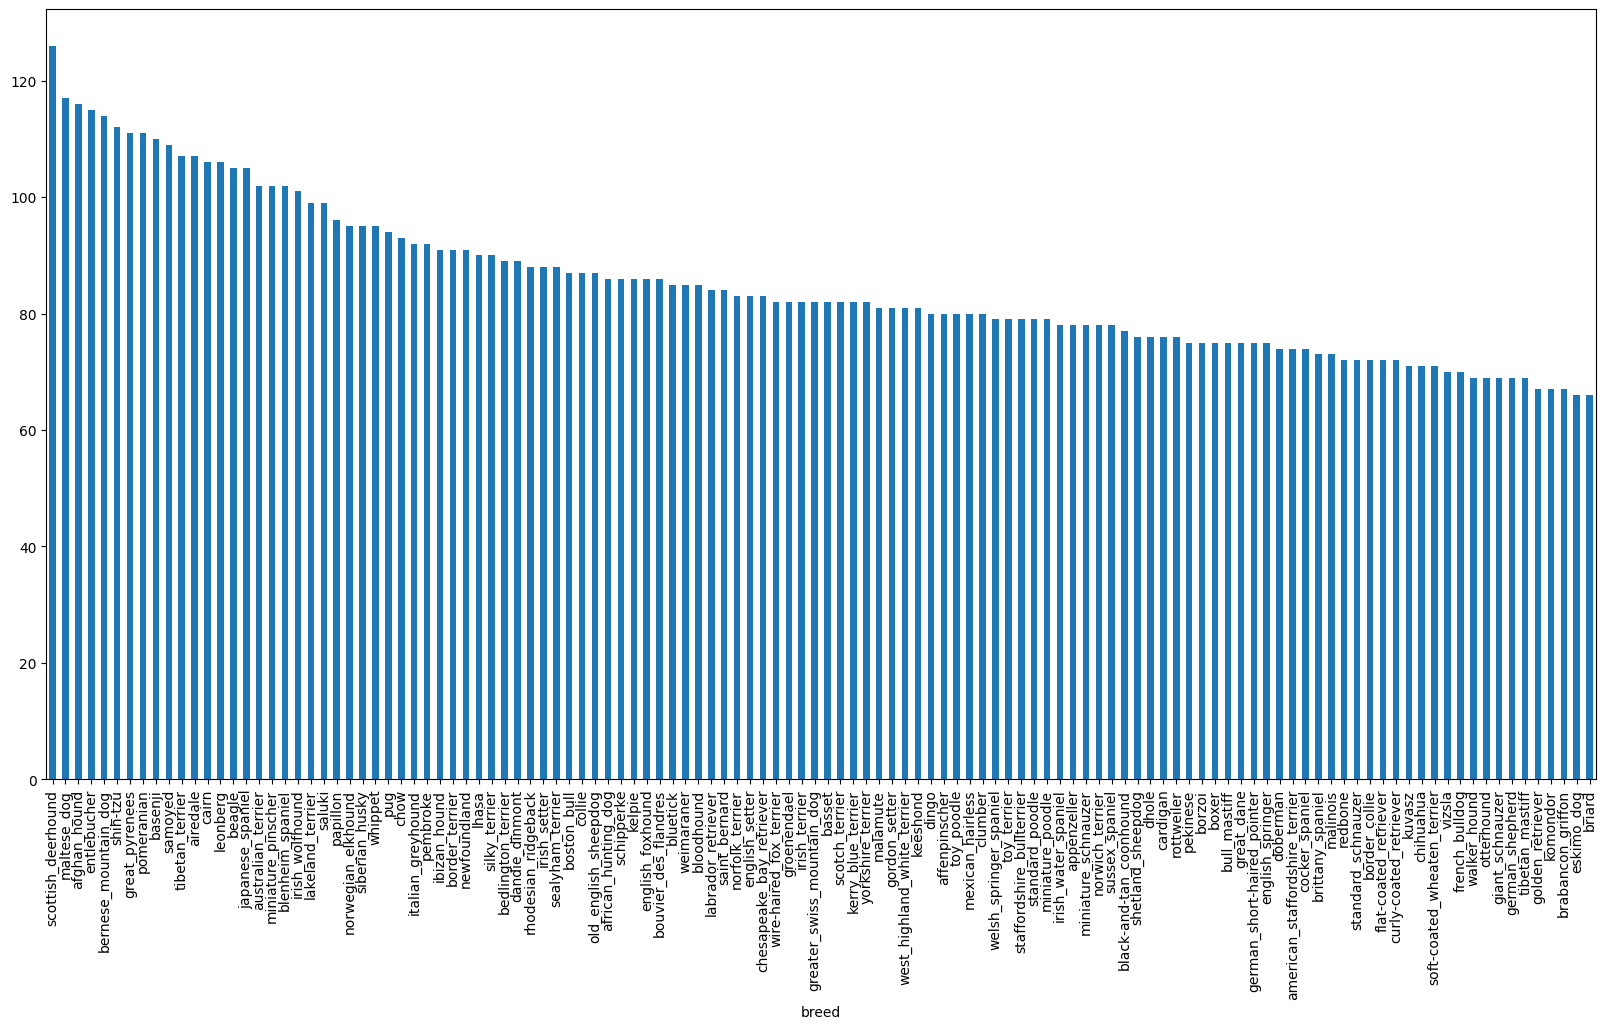

In [3]:
#Find out how many dog breeds are there for each class and plot
labels_csv["breed"].value_counts().plot.bar(figsize=(20,10))

In [4]:
print(labels_csv["breed"].value_counts().mean())

85.18333333333334


In [5]:
#Viewing an image inside the notebook -- copy the image file path and include image id

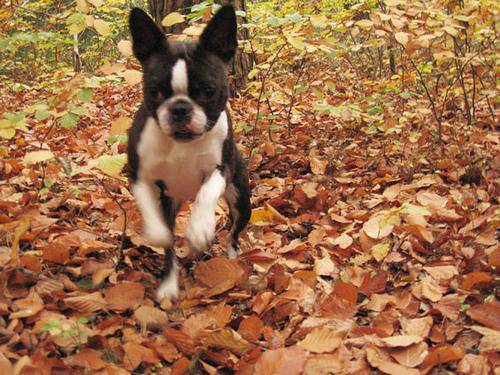

In [6]:
from IPython.display import Image
Image("/Users/lukeopany/Desktop/dog-vision/train/000bec180eb18c7604dcecc8fe0dba07.jpg")

Because it would take a lot of time to type out the filepath each time we need to get an image, we are going to create a pathname from image IDs

In [7]:
#Create pathname from image ID's
filename = "/Users/lukeopany/Desktop/dog-vision/train/" + labels_csv["id"] + ".jpg"
# Avoid printing the full Series (can freeze the notebook output)
filename.head()

0    /Users/lukeopany/Desktop/dog-vision/train/000b...
1    /Users/lukeopany/Desktop/dog-vision/train/0015...
2    /Users/lukeopany/Desktop/dog-vision/train/001c...
3    /Users/lukeopany/Desktop/dog-vision/train/0021...
4    /Users/lukeopany/Desktop/dog-vision/train/0021...
Name: id, dtype: str

In [8]:
#Check whether the number of filenames matches the number of actual images

In [9]:
import os

# Get the list of all files in the training directory
train_path = "/Users/lukeopany/Desktop/dog-vision/train/"
files = os.listdir(train_path)

# Compare the lengths
print(f"Number of filenames generated: {len(filename)}")
print(f"Number of actual images in folder: {len(files)}")

if len(filename) == len(files):
    print("Success: The number of filenames matches the number of actual images.")
else:
    print("Warning: The number of filenames does not match the number of actual images.")

Number of filenames generated: 10222
Number of actual images in folder: 10222
Success: The number of filenames matches the number of actual images.


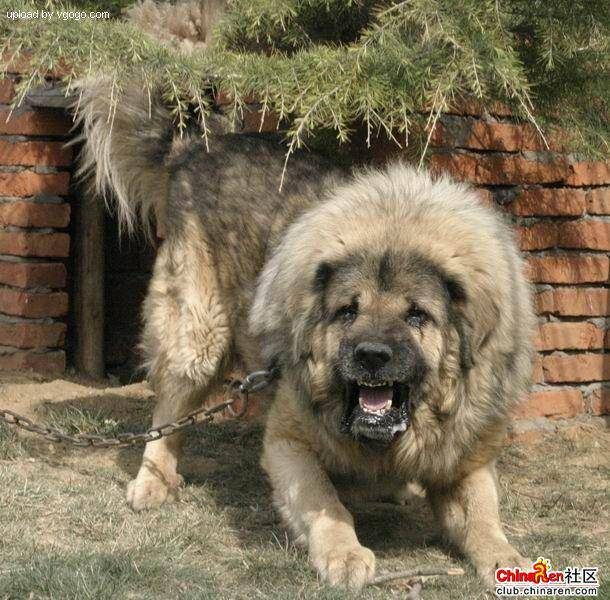

In [10]:
#One more check
from IPython.display import Image
Image(filename[9000])

In [11]:
labels_csv['breed'][9000]

'tibetan_mastiff'

Since we've now got our training image filepath in a list, let's prepare our lables

In [12]:
import numpy as np
labels = labels_csv['breed']
labels = np.array(labels)
len(labels)

10222

In [13]:
#compare the number of labels to the number in files

In [14]:
# Compare the number of labels to the number of actual images in the folder
print(f"Number of labels: {len(labels)}")
print(f"Number of actual images in folder: {len(files)}")

if len(labels) == len(files):
    print("Success: The number of labels matches the number of actual images.")
else:
    print("Warning: There is a mismatch between the number of labels and image files.")

Number of labels: 10222
Number of actual images in folder: 10222
Success: The number of labels matches the number of actual images.


In [15]:
# Find the unique value labels
unique_breeds = np.unique(labels)
len(unique_breeds)

120

In [16]:
# Turn a single label into an array of booleans
labels[0] == unique_breeds

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [17]:
# Turn every label into an array of booleans
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [18]:
len(boolean_labels)

10222

In [19]:
# Example: Turning a boolean array into integers
print(labels[0]) # Original labels
print(np.where(unique_breeds == labels[0])) #index where label occurs
print(boolean_labels[0].argmax()) # index where label occurs in boolean array
print(boolean_labels[0].astype(int)) # There will be a 1 where the sample occurs



boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [20]:
print(labels[2])
print(boolean_labels[2].astype(int))


pekinese
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [21]:
filename[:10]

0    /Users/lukeopany/Desktop/dog-vision/train/000b...
1    /Users/lukeopany/Desktop/dog-vision/train/0015...
2    /Users/lukeopany/Desktop/dog-vision/train/001c...
3    /Users/lukeopany/Desktop/dog-vision/train/0021...
4    /Users/lukeopany/Desktop/dog-vision/train/0021...
5    /Users/lukeopany/Desktop/dog-vision/train/0022...
6    /Users/lukeopany/Desktop/dog-vision/train/0029...
7    /Users/lukeopany/Desktop/dog-vision/train/002a...
8    /Users/lukeopany/Desktop/dog-vision/train/003d...
9    /Users/lukeopany/Desktop/dog-vision/train/0042...
Name: id, dtype: str

This whole process has been trying to get our data into an accesible format

Creating our own validation set

In [22]:
#This can be achieved by creating the X and y variable (normally for test-train split but can be used in our case to split the data into train - val)

In [23]:
x = filename
y = boolean_labels

In [24]:
len(x), len(y)

(10222, 10222)

In [25]:
#To save time, start with ~1000 samples 

In [26]:
# Set the number of images to use for experimenting
NUM_IMAGES = 1000
# Split into train and validation sets (80/20 split)
NUM_TRAIN = int(NUM_IMAGES * 0.8)  # 800 images for training -- int ensures no float(decimals)

x_train = x[:NUM_TRAIN]
y_train = y[:NUM_TRAIN]

x_val = x[NUM_TRAIN:NUM_IMAGES]
y_val = y[NUM_TRAIN:NUM_IMAGES]

print(f"Training samples:   {len(x_train)}")
print(f"Validation samples: {len(x_val)}")

Training samples:   800
Validation samples: 200


In [27]:
x_train[:5], y_train[:2]

(0    /Users/lukeopany/Desktop/dog-vision/train/000b...
 1    /Users/lukeopany/Desktop/dog-vision/train/0015...
 2    /Users/lukeopany/Desktop/dog-vision/train/001c...
 3    /Users/lukeopany/Desktop/dog-vision/train/0021...
 4    /Users/lukeopany/Desktop/dog-vision/train/0021...
 Name: id, dtype: str,
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False,  True, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False

Since our labels are already numerical, let's turn our images(filepaths) into tensors

Tensors are a numerical representation -- kind of like a matrix

Write a function to turn a file path into a tensor
 1. Take an image file path as input
 2. Use TensorFlow to read the image from the file and save it to a variable 'image'
 3. Turn our 'image' into a tensors
 4. Normalize our image: Convert color channels from 0-255 to 0-1
 5. Resize the image to a target size (e.g., 224x224 pixels)
 6. Return the modified 'image'

In [28]:
from matplotlib.pyplot import imread
image = imread(x_train[0])
image.max(), image.min(), image.shape, image[:2]

(255,
 0,
 (375, 500, 3),
 array([[[108,  46,   0],
         [152,  92,  42],
         [180, 120,  70],
         ...,
         [176, 144,  69],
         [189, 157,  82],
         [214, 182, 107]],
 
        [[151,  93,  47],
         [179, 121,  75],
         [167, 111,  64],
         ...,
         [167, 136,  56],
         [172, 139,  60],
         [188, 157,  77]]], dtype=uint8))

In [29]:
#Turn image into a tensor (this is what an image looks like as a tensor)
tf.constant(image)[:2]

<tf.Tensor: shape=(2, 500, 3), dtype=uint8, numpy=
array([[[108,  46,   0],
        [152,  92,  42],
        [180, 120,  70],
        ...,
        [176, 144,  69],
        [189, 157,  82],
        [214, 182, 107]],

       [[151,  93,  47],
        [179, 121,  75],
        [167, 111,  64],
        ...,
        [167, 136,  56],
        [172, 139,  60],
        [188, 157,  77]]], dtype=uint8)>

In [30]:
#Define image size(ensures images are the same size)
IMAGE_SIZE = (224, 224)

#Create a function for preprocessing an images
def preprocess_image(file_path):
    # Read the image from the file
    image = tf.io.read_file(file_path)
    # Decode the image into a tensor
    image = tf.image.decode_jpeg(image, channels=3)
    # Normalize pixel values from [0, 255] to [0, 1]
    image = tf.image.convert_image_dtype(image, tf.float32)
    # Resize the image to the target size
    image = tf.image.resize(image, IMAGE_SIZE)
    return image

In [31]:
#Turning our data into batches so they process efficiently
#create a simple function to return a tuple of tensors (preprocessed image, label)
def get_image_label(image_path, label):
    image = preprocess_image(image_path)
    return image, label

In [32]:
#Demo of the functiona above
get_image_label(x_train[0], tf.constant(y_train[0]))

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.5705322 , 0.33588538, 0.15008473],
         [0.66901225, 0.4601166 , 0.26022965],
         [0.61062384, 0.43763596, 0.21601713],
         ...,
         [0.8182312 , 0.7297958 , 0.26963907],
         [0.72454786, 0.6059109 , 0.2653059 ],
         [0.7494603 , 0.6252918 , 0.32456532]],
 
        [[0.6761415 , 0.4733761 , 0.30642927],
         [0.5672121 , 0.38192675, 0.20349538],
         [0.5883547 , 0.4322571 , 0.2403155 ],
         ...,
         [0.9326942 , 0.8260503 , 0.41093278],
         [0.86072475, 0.74250627, 0.3694122 ],
         [0.76781666, 0.6461604 , 0.29291284]],
 
        [[0.46350825, 0.29595745, 0.1536156 ],
         [0.42554107, 0.27039403, 0.12009468],
         [0.7887875 , 0.6547362 , 0.49015   ],
         ...,
         [0.89372385, 0.7696401 , 0.41811958],
         [0.88609535, 0.7585918 , 0.36495727],
         [0.8243601 , 0.69494826, 0.2930575 ]],
 
        ...,
 
        [[0.7344025 , 0.4716574 

In [33]:
BATCH_SIZE = 32

def create_data_batches(x, y=None, batch_size=BATCH_SIZE, valid_data=False, test_data=False):
    if test_data:
        data = tf.data.Dataset.from_tensor_slices(tf.constant(x))
        data = data.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
        data = data.batch(batch_size)
        data = data.prefetch(tf.data.AUTOTUNE)
        return data

    y = np.array(y).astype(np.float32)

    data = tf.data.Dataset.from_tensor_slices((tf.constant(x), tf.constant(y)))

    if not valid_data:
        data = data.shuffle(buffer_size=len(x))

    data = data.map(get_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    data = data.batch(batch_size)
    data = data.prefetch(tf.data.AUTOTUNE)

    return data

In [34]:
train_data = create_data_batches(x_train, y_train)
val_data = create_data_batches(x_val, y_val, valid_data=True)

print(train_data.element_spec)

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.float32, name=None))


In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function for viewing images
def show_25_images(images, labels, unique_breeds):
    """
    Displays a plot of 25 images and their labels from a data batch.
    """
    # Setup the figure size (10 inches by 10 inches)
    plt.figure(figsize=(10, 10))
    
    # Loop through 25 (for displaying 25 images)
    for i in range(25):
        # Create subplots (5 rows, 5 columns)
        # The i+1 is because matplotlib subplots are 1-indexed
        ax = plt.subplot(5, 5, i + 1)
        
        # Display an image
        plt.imshow(images[i])
        
        # Add the image label as the title
        # labels[i].argmax() finds the index of the highest value (the "1" in one-hot encoding)
        plt.title(unique_breeds[labels[i].argmax()])
        
        # Turn the grid lines and axes off for a clean look
        plt.axis("off")




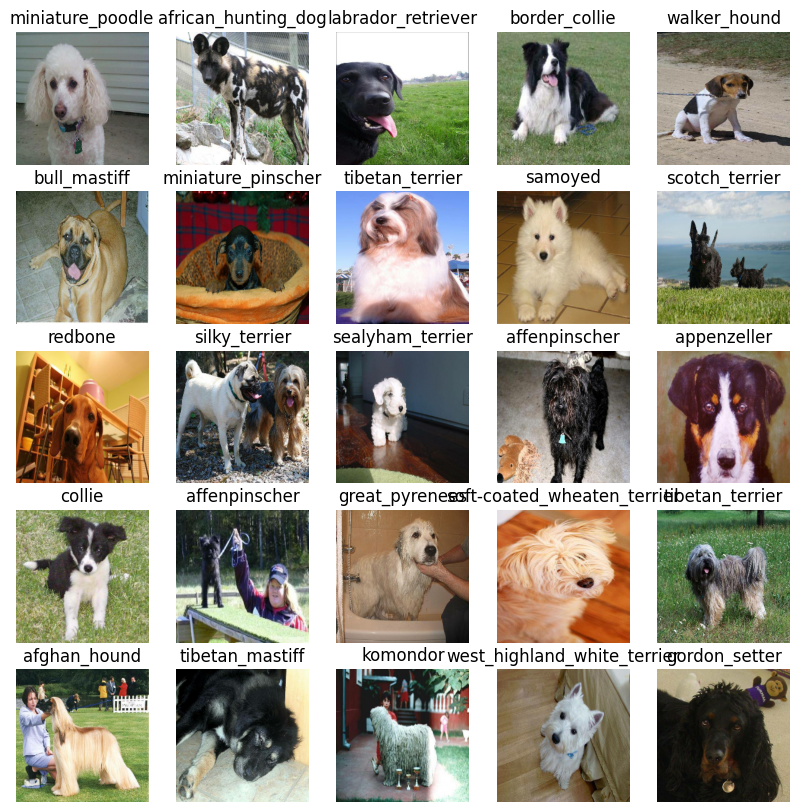

In [36]:
show_25_images(*train_data.as_numpy_iterator().next(), unique_breeds=unique_breeds)

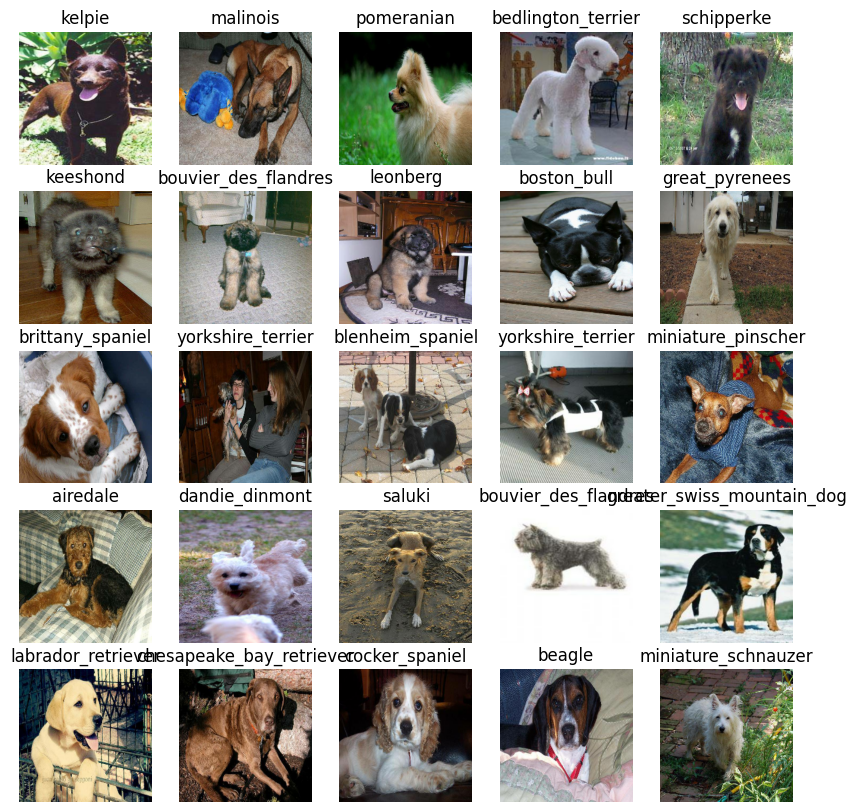

In [37]:
show_25_images(*val_data.as_numpy_iterator().next(), unique_breeds=unique_breeds)

For builfing a model, these are the standard practices: 

1. The input shape (our images in the form of Tensors) to our model
2. The output shape (image labels (y), in the form of Tensors) of our model
3. The URL of the model (we are not building from scratch) 

In [38]:
INPUT_SHAPE = IMAGE_SIZE + (3,)  # height, width, color channels
OUTPUT_SHAPE = len(unique_breeds)  # number of unique dog breeds (120)
MODEL_URL = "https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/140-224-feature-vector/2"


In [39]:
len(unique_breeds)

120

From here, we can use the above variables to build a model using transfer learning. So let's create a function that; 
1. Takes in the input shape, output shape and model URL
2. Defines the layers in Keras model in sequential fashion 
3. Compiles the model
4. Builds and Returns the model 

In [ ]:
def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE, model_url=MODEL_URL):
    print("Building model with:", model_url)
    
    model = tf.keras.Sequential([
        hub.KerasLayer(model_url, 
                       trainable=False,
                       input_shape=input_shape),  # (224, 224, 3)
        tf.keras.layers.Dense(units=output_shape, 
                              activation="softmax")
    ])
    
    model.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.legacy.Adam(),
        metrics=["accuracy"]
    )
    
    return model


In [41]:
model = create_model()
model.summary()

Building model with: https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/140-224-feature-vector/2


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1792)              4363712   
                                                                 
 dense (Dense)               (None, 120)               215160    
                                                                 
Total params: 4578872 (17.47 MB)
Trainable params: 215160 (840.47 KB)
Non-trainable params: 4363712 (16.65 MB)
_________________________________________________________________


Create two callbacks 
1. For tensorboard to help track our model's progress, check it's progress or stop training early
2. For early stopping to stop training if the model isn't improving after a certain number of epochs (patience)

Three things to do before creating a TensorBoard callback:
1. Load the TensorBoard extension
2. Create a TensorBoard callback which saves logs to a directory and pass it to our model's fit method
3. View the TensorBoard logs in the notebook using the %tensorboard magic command

In [43]:
#Creating a TensorBoard callback
import os
import datetime
import tensorflow as tf

# Create a function to build a TensorBoard callback
def create_tensorboard_callback():
    logdir = os.path.join("logs",
                          datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
    return tf.keras.callbacks.TensorBoard(logdir)

In [44]:
#Creating a EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)

Training our model on a subset of the data (to save time)


In [45]:
NUM_EPOCHS = 100

Let's create a function which trains a model.

• Create a model using create_model()

• Setup a TensorBoard callback using create_tensorboard_callback()

• Call the fit() function on our model passing it the training data, validation data, number of epochs to train for (NUM_EPOCHS) and the callbacks we'd like to use

• Return the model

In [46]:
def train_model():
    model = create_model()
    tensorboard = create_tensorboard_callback()
    model.fit(x=train_data,
              epochs=NUM_EPOCHS,
              validation_data=val_data,
              validation_freq=1,
              callbacks=[tensorboard, early_stopping])
    return model


In [47]:
model = train_model()

Building model with: https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/140-224-feature-vector/2


Epoch 1/100
25/25 [==============================] - 29s 667ms/step - loss: 4.1280 - accuracy: 0.1925 - val_loss: 3.0532 - val_accuracy: 0.2950
Epoch 2/100
25/25 [==============================] - 22s 883ms/step - loss: 1.2534 - accuracy: 0.8200 - val_loss: 1.8474 - val_accuracy: 0.5500
Epoch 3/100
25/25 [==============================] - 21s 833ms/step - loss: 0.4188 - accuracy: 0.9762 - val_loss: 1.5283 - val_accuracy: 0.5900
Epoch 4/100
25/25 [==============================] - 20s 811ms/step - loss: 0.2071 - accuracy: 0.9950 - val_loss: 1.4566 - val_accuracy: 0.6050
Epoch 5/100
25/25 [==============================] - 25s 998ms/step - loss: 0.1312 - accuracy: 0.9987 - val_loss: 1.3903 - val_accuracy: 0.6200
Epoch 6/100
25/25 [==============================] - 22s 879ms/step - loss: 0.0940 - accuracy: 1.0000 - val_loss: 1.3636 - val_accuracy: 0.6250
Epoch 7/100
25/25 [==============================] - 26s 1s/step - loss: 0.0727 - accuracy: 1.0000 - val_loss: 1.3460 - val_accuracy: 0.

From the results above, it looks like our model is overfitting because it's performing far better on the training dataset than the validation dataset, we need to find a a way to prevent or reduce this. But overfitting to begin with is a good thing! It means our model is learning!

In [48]:
#Making and evaluating predictions with our model
predictions  = model.predict(val_data, verbose=1)
predictions


7/7 [==============================] - 9s 1s/step


array([[1.0959142e-03, 1.1470496e-04, 2.4915871e-03, ..., 6.0432329e-04,
        1.5884374e-04, 7.0309819e-04],
       [6.3370528e-05, 1.2045321e-03, 3.0297993e-04, ..., 1.3263369e-03,
        7.1876661e-05, 2.6832451e-04],
       [7.2200011e-05, 7.4979180e-05, 3.5456185e-05, ..., 7.6264919e-06,
        5.0266823e-07, 6.4549578e-04],
       ...,
       [1.9720956e-03, 4.8220257e-04, 3.4538022e-04, ..., 8.6649197e-05,
        2.6735470e-05, 9.9366727e-05],
       [4.6211918e-04, 2.0873242e-03, 1.2170952e-04, ..., 8.1369908e-05,
        2.9007191e-05, 3.3989108e-06],
       [3.6003644e-04, 1.4728266e-02, 6.5621716e-04, ..., 5.3490384e-04,
        2.4028953e-02, 1.4127429e-04]], dtype=float32)

In [50]:
np.sum(predictions[0])

1.0

In [58]:
index = 21
print(predictions[index])
print(f"Max value (probability of prediction): {np.max(predictions[index])}")
print(f"Sum: {np.sum(predictions[index])}")
print(f"Max index: {np.argmax(predictions[index])}")
print(f"Predicted label: {unique_breeds[np.argmax(predictions[index])]}")


[7.23298353e-06 3.08795861e-05 5.93601762e-05 1.90646009e-04
 2.28040488e-04 7.10329323e-06 1.78299126e-06 1.93601627e-05
 1.18209127e-05 2.19344238e-05 5.92891456e-06 1.89801794e-05
 8.22367947e-05 1.92965945e-06 3.93618247e-04 1.22882766e-05
 4.02859268e-06 1.28568790e-04 1.41231703e-06 5.77784567e-06
 1.96034343e-05 1.24585513e-05 1.42077588e-05 1.18095440e-05
 2.33541487e-05 2.32434628e-04 2.41969815e-06 8.30015779e-06
 9.76593614e-01 6.50482343e-06 1.68155634e-06 6.78671631e-06
 1.14036984e-05 2.07797234e-06 1.44762709e-03 2.22871913e-05
 1.35645751e-05 6.06454123e-05 2.27102155e-05 2.18848072e-06
 8.13382121e-06 4.98714508e-06 3.33328444e-06 1.49972429e-05
 5.71077944e-05 1.31468664e-06 7.67266556e-06 3.58512800e-04
 5.54913131e-05 8.54118334e-05 3.59966918e-07 4.13192698e-04
 3.35137192e-05 1.71835891e-05 2.99858912e-05 9.40970767e-06
 1.81329615e-05 1.27321400e-04 2.63438444e-04 5.79896332e-05
 7.06276769e-05 3.36002216e-07 1.33385947e-05 7.20740063e-05
 1.39633512e-05 9.815832

In [62]:
#Turn predictions into labels
predicted_labels = [unique_breeds[np.argmax(pred)] for pred in predictions]
predicted_labels[81]

'irish_terrier'

In [60]:
# Turn prediction probabilities into their respective label (easier to understand)
def get_pred_label(prediction_probabilities):
  """
  Turns an array of prediction probabilities into a label.
  """
  return unique_breeds[np.argmax(prediction_probabilities)]

# Get a predicted label based on an array of prediction probabilities
pred_label = get_pred_label(predictions[20])
pred_label


'labrador_retriever'

Since the validation data is still in a batch, we need to unbatch. 

In [64]:
# Create a function to unbatch a batch dataset
def unbatchify(data):
  """
  Takes a batched dataset of (image, label) Tensors and returns separate arrays
  of images and labels.
  """
  images = []
  labels = []
  # Loop through unbatched data
  for image, label in data.unbatch().as_numpy_iterator():
    images.append(image)
    labels.append(unique_breeds[np.argmax(label)])
  return images, labels

# Unbatchify the validation data
val_images, val_labels = unbatchify(val_data)
val_images[0], val_labels[0]

2026-03-09 16:47:10.418161: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(array([[[0.8355043 , 0.98298323, 0.70532215],
         [0.7773548 , 0.94725144, 0.6567314 ],
         [0.72830886, 0.9062676 , 0.6305935 ],
         ...,
         [0.5036765 , 0.6010855 , 0.48595938],
         [0.24266897, 0.34007794, 0.22495186],
         [0.11470589, 0.21211486, 0.0969888 ]],
 
        [[0.6267507 , 0.8260505 , 0.5357143 ],
         [0.6932073 , 0.8988796 , 0.60865724],
         [0.7595764 , 0.9580533 , 0.69399947],
         ...,
         [0.21892071, 0.31492913, 0.22242211],
         [0.09321605, 0.18922445, 0.09671745],
         [0.16456583, 0.26057425, 0.16806723]],
 
        [[0.40098044, 0.6521009 , 0.3721289 ],
         [0.45759374, 0.7125263 , 0.43192846],
         [0.51861   , 0.7825106 , 0.5060531 ],
         ...,
         [0.27365196, 0.36657035, 0.30824578],
         [0.11444326, 0.20421043, 0.1490371 ],
         [0.1497199 , 0.24460787, 0.18431373]],
 
        ...,
 
        [[0.94565725, 0.9590328 , 0.8931364 ],
         [0.93780744, 0.9536863 , 0.88403

Function visualizes a single image from a validation set -- the two examples below illustrate that. The images here are from the validation dataset

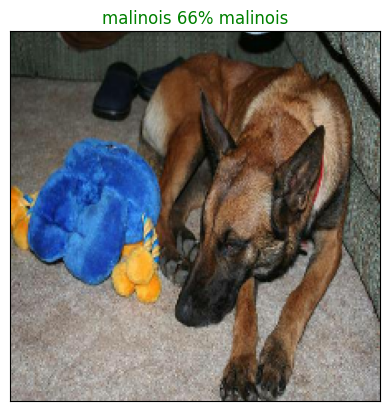

In [66]:
def plot_pred(prediction_probabilities, labels, images, n=1):
    """
    View the prediction, ground truth and image for sample n
    """
    pred_prob, true_label, image = prediction_probabilities[n], labels[n], images[n]

    # Get the pred label
    pred_label = get_pred_label(pred_prob)

    # Plot image & remove ticks
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])

    #change the color of the title based on whether the prediction is right or wrong
    if pred_label == true_label:
        color = "green"
    else:
        color = "red"

    # Change plot title to be predicted, probability of prediction and truth label
    plt.title("{} {:2.0f}% {}".format(pred_label,
                                      np.max(pred_prob)*100,
                                      true_label),
              color=color)

# Example usage:
plot_pred(prediction_probabilities=predictions,
          labels=val_labels,
          images=val_images)

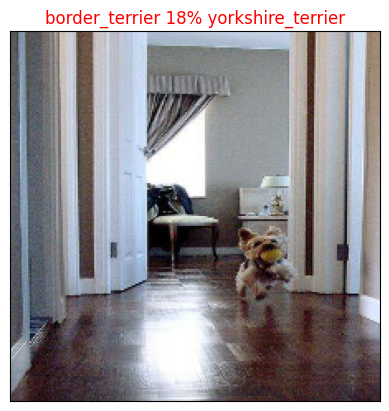

In [67]:
def plot_pred(prediction_probabilities, labels, images, n=72):
    """
    View the prediction, ground truth and image for sample n
    """
    pred_prob, true_label, image = prediction_probabilities[n], labels[n], images[n]

    # Get the pred label
    pred_label = get_pred_label(pred_prob)

    # Plot image & remove ticks
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])

    #change the color of the title based on whether the prediction is right or wrong
    if pred_label == true_label:
        color = "green"
    else:
        color = "red"

    # Change plot title to be predicted, probability of prediction and truth label
    plt.title("{} {:2.0f}% {}".format(pred_label,
                                      np.max(pred_prob)*100,
                                      true_label),
              color=color)

# Example usage:
plot_pred(prediction_probabilities=predictions,
          labels=val_labels,
          images=val_images)

The function above visualizes a single image, we need one for the top 10 predictions

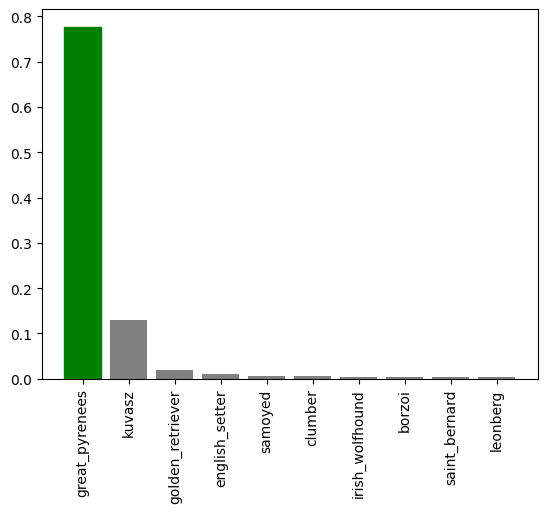

In [69]:
def plot_pred_conf(prediction_probabilities, labels, n=1):
    """
    Plots the top 10 highest prediction confidences along with the truth label for sample n.
    """
    pred_prob, true_label = prediction_probabilities[n], labels[n]

    # Get the predicted label
    pred_label = get_pred_label(pred_prob)

    # Find the top 10 prediction confidence indexes
    top_10_pred_indexes = pred_prob.argsort()[-10:][::-1]
    
    # Find the top 10 prediction confidence values
    top_10_pred_values = pred_prob[top_10_pred_indexes]
    
    # Find the top 10 prediction labels
    top_10_pred_labels = unique_breeds[top_10_pred_indexes]

    # Setup plot
    top_plot = plt.bar(np.arange(len(top_10_pred_labels)), 
                       top_10_pred_values, 
                       color="grey")
    
    plt.xticks(np.arange(len(top_10_pred_labels)),
               labels=top_10_pred_labels,
               rotation="vertical")
    # Change color of true label
    if np.isin(true_label, top_10_pred_labels):
        top_plot[np.argmax(top_10_pred_labels == true_label)].set_color("green")
    else:
        pass

# Call the function
plot_pred_conf(prediction_probabilities=predictions,
               labels=val_labels,
               n=9)

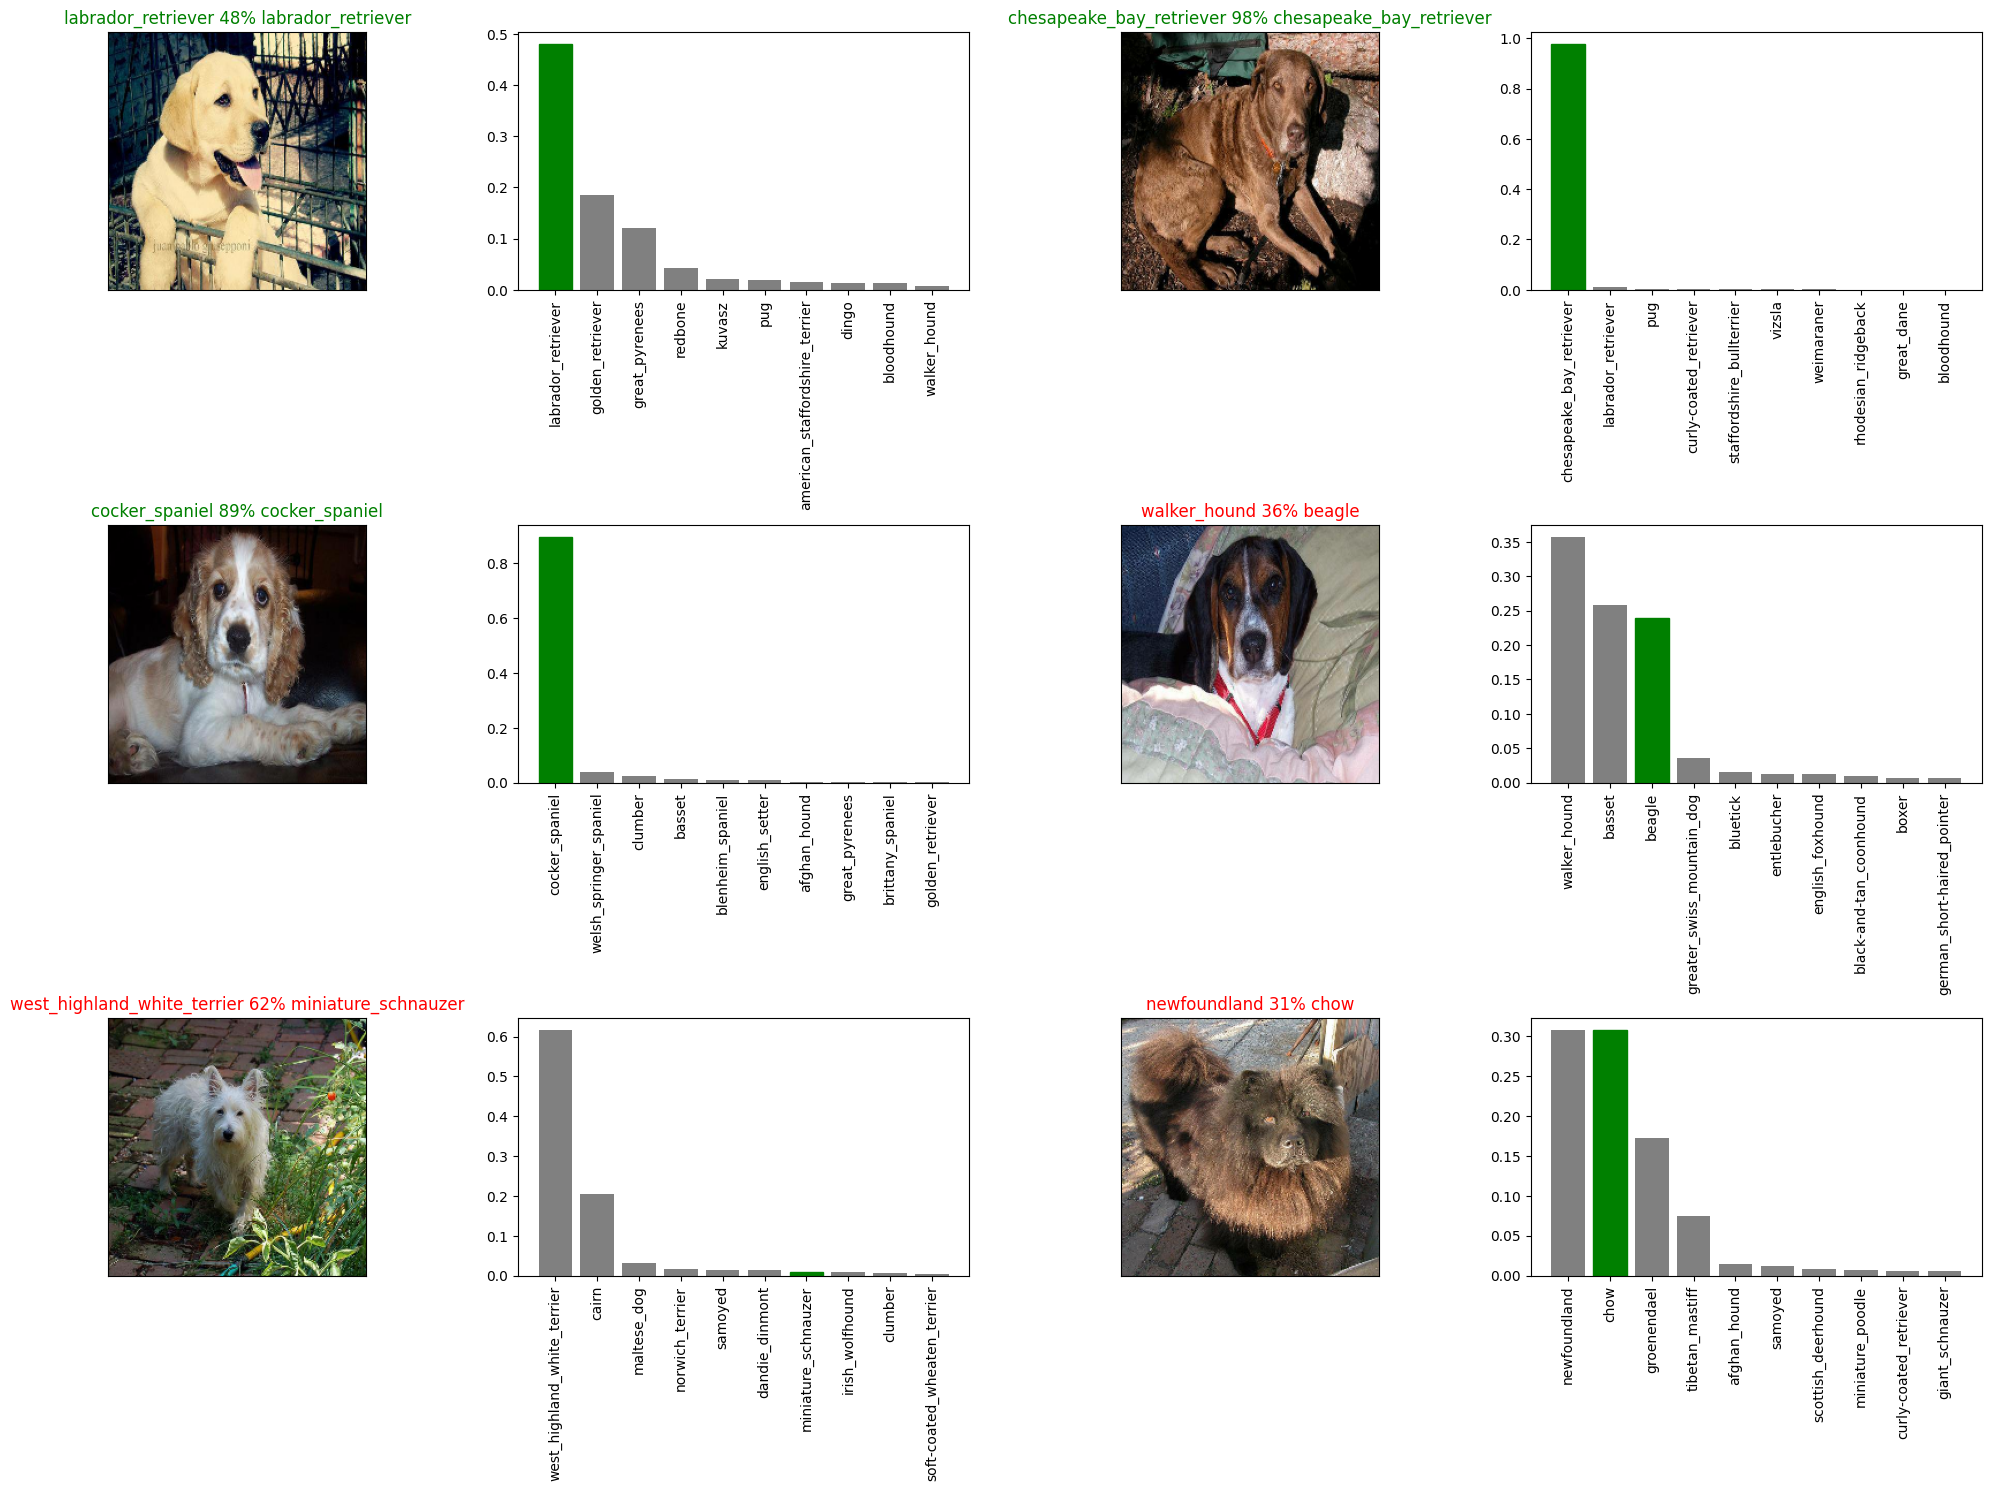

In [73]:
#Predictions and their different values
i_multiplier = 20
num_rows = 3
num_cols = 2
num_images = num_rows * num_cols
plt.figure(figsize=(10 * num_cols, 5 * num_rows))

for i in range(num_images):
  plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
  plot_pred(prediction_probabilities=predictions,
            labels=val_labels,
            images=val_images,
            n=i + i_multiplier)
  
  plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
  plot_pred_conf(prediction_probabilities=predictions,
                 labels=val_labels,
                 n=i + i_multiplier)
plt.tight_layout()
plt.show()

In [74]:
model.save("dog_vision_model")

INFO:tensorflow:Assets written to: dog_vision_model/assets


INFO:tensorflow:Assets written to: dog_vision_model/assets


In [76]:
# Train on the full dataset
# Split the full dataset (80/20 train/val)
NUM_IMAGES_FULL = len(x)
NUM_TRAIN_FULL = int(NUM_IMAGES_FULL * 0.8)

x_train_full = x[:NUM_TRAIN_FULL]
y_train_full = y[:NUM_TRAIN_FULL]

x_val_full = x[NUM_TRAIN_FULL:NUM_IMAGES_FULL]
y_val_full = y[NUM_TRAIN_FULL:NUM_IMAGES_FULL]

print(f"Full training samples:   {len(x_train_full)}")
print(f"Full validation samples: {len(x_val_full)}")


Full training samples:   8177
Full validation samples: 2045


In [77]:
# Create data batches for the full dataset
train_data_full = create_data_batches(x_train_full, y_train_full)
val_data_full = create_data_batches(x_val_full, y_val_full, valid_data=True)

print(train_data_full.element_spec)


(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.float32, name=None))


In [78]:
# Train the model on the full dataset
def train_model_full():
    model = create_model()
    tensorboard = create_tensorboard_callback()
    model.fit(x=train_data_full,
              epochs=NUM_EPOCHS,
              validation_data=val_data_full,
              validation_freq=1,
              callbacks=[tensorboard, early_stopping])
    return model

full_model = train_model_full()


Building model with: https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/140-224-feature-vector/2


Epoch 1/100
256/256 [==============================] - 166s 636ms/step - loss: 1.3458 - accuracy: 0.6793 - val_loss: 0.6533 - val_accuracy: 0.8049
Epoch 2/100
256/256 [==============================] - 161s 629ms/step - loss: 0.3469 - accuracy: 0.9066 - val_loss: 0.5831 - val_accuracy: 0.8132
Epoch 3/100
256/256 [==============================] - 4013s 16s/step - loss: 0.1988 - accuracy: 0.9551 - val_loss: 0.5514 - val_accuracy: 0.8176
Epoch 4/100
256/256 [==============================] - 161s 628ms/step - loss: 0.1227 - accuracy: 0.9792 - val_loss: 0.5522 - val_accuracy: 0.8166
Epoch 5/100
256/256 [==============================] - 750s 3s/step - loss: 0.0843 - accuracy: 0.9898 - val_loss: 0.5385 - val_accuracy: 0.8254
Epoch 6/100
256/256 [==============================] - 167s 654ms/step - loss: 0.0578 - accuracy: 0.9954 - val_loss: 0.5275 - val_accuracy: 0.8254
Epoch 7/100
256/256 [==============================] - 192s 749ms/step - loss: 0.0436 - accuracy: 0.9974 - val_loss: 0.530

Making Predictions on the test dataset

In [85]:
# Load test image filepaths
test_path = "/Users/lukeopany/Desktop/dog-vision/test/"
test_filenames = [test_path + fname for fname in os.listdir(test_path)]
print(f"Number of test images: {len(test_filenames)}")
test_filenames[:5]


Number of test images: 10357


['/Users/lukeopany/Desktop/dog-vision/test/266490a2b053a4a3bf68e779f28fb5a9.jpg',
 '/Users/lukeopany/Desktop/dog-vision/test/dae9fd18836d8df20989ef0101771d4b.jpg',
 '/Users/lukeopany/Desktop/dog-vision/test/079a40f22b0fad9a66f76797b62bb930.jpg',
 '/Users/lukeopany/Desktop/dog-vision/test/ab8462f9a501d362041d47582fddc9ad.jpg',
 '/Users/lukeopany/Desktop/dog-vision/test/8895089b432e020cc42e6262b5a1c2dd.jpg']

In [80]:
# Create test data batches (no labels since this is test data)
test_data = create_data_batches(test_filenames, test_data=True)
print(test_data.element_spec)


TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)


In [81]:
# Make predictions on the test dataset using the full model
test_predictions = full_model.predict(test_data, verbose=1)
test_predictions.shape


324/324 [==============================] - 170s 522ms/step


(10357, 120)

In [82]:
# Build the submission DataFrame: image id + one probability column per breed
test_ids = [os.path.splitext(os.path.basename(f))[0] for f in test_filenames]

submission_df = pd.DataFrame(test_predictions, columns=unique_breeds)
submission_df.insert(0, "id", test_ids)

submission_df.to_csv("full_model_predictions.csv", index=False)
print(f"Submission saved! Shape: {submission_df.shape}")
submission_df.head()


Submission saved! Shape: (10357, 121)


,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,266490a2b053a4a3bf68e779f28fb5a9,8.185506e-09,4.505433e-05,4.986244e-06,1.308385e-06,5.373846e-07,2.639123e-06,4.033711e-10,1.192313e-07,1.559347e-03,...,7.860908e-08,9.143111e-09,4.993525e-04,3.731073e-05,1.577323e-03,1.952221e-07,1.927113e-08,2.363073e-05,2.470505e-08,1.574539e-08
1,dae9fd18836d8df20989ef0101771d4b,3.921052e-04,2.025018e-03,2.982268e-06,1.830755e-07,4.263012e-08,3.349914e-08,1.073289e-04,1.552909e-07,2.417625e-07,...,4.723498e-06,5.764831e-08,9.469658e-06,1.424945e-07,1.261493e-06,1.421856e-08,1.316667e-06,1.693633e-05,6.386088e-07,2.364507e-07
2,079a40f22b0fad9a66f76797b62bb930,3.453493e-05,1.733938e-06,1.229900e-07,6.017164e-09,2.599121e-08,4.873231e-08,1.123185e-09,1.413786e-08,6.131782e-09,...,9.090293e-07,5.052819e-10,6.503789e-08,1.641953e-07,3.008766e-08,3.809923e-10,2.679687e-09,1.346666e-08,2.135243e-09,6.049847e-09
3,ab8462f9a501d362041d47582fddc9ad,1.676264e-07,1.402151e-06,2.596864e-09,4.208656e-07,1.526961e-10,1.598959e-07,8.369636e-08,1.110079e-10,1.059061e-07,...,2.145026e-06,5.707179e-09,4.098836e-08,2.295951e-09,1.261846e-09,1.479235e-07,1.989267e-09,9.572373e-10,6.244266e-10,1.189001e-06
4,8895089b432e020cc42e6262b5a1c2dd,2.721278e-10,1.950271e-09,1.574162e-07,4.595596e-09,1.536279e-07,9.426639e-07,5.560163e-07,3.174154e-04,2.017943e-07,...,6.023229e-09,1.875119e-08,2.034299e-09,6.912720e-08,3.092201e-09,6.274832e-07,1.524882e-08,2.676999e-07,1.183464e-09,1.511233e-08


In [83]:
test_predictions[:5]

array([[8.18550561e-09, 4.50543303e-05, 4.98624377e-06, 1.30838453e-06,
        5.37384608e-07, 2.63912284e-06, 4.03371059e-10, 1.19231316e-07,
        1.55934680e-03, 1.34197296e-06, 3.11794975e-06, 7.55113216e-09,
        6.50073707e-01, 3.27037313e-08, 2.59654015e-01, 5.35956770e-03,
        1.49097289e-07, 1.33024325e-09, 3.59785503e-07, 4.43992221e-08,
        7.99493947e-08, 1.15634620e-07, 6.40193178e-08, 5.01258555e-08,
        6.84784851e-09, 2.23237890e-07, 2.02694093e-08, 9.76152918e-08,
        4.62064327e-06, 3.65287001e-08, 1.08774623e-09, 1.84457167e-05,
        8.90389458e-07, 5.18173124e-07, 6.00578605e-05, 1.85166478e-08,
        1.82697349e-07, 5.09710958e-08, 2.98554706e-03, 2.58897376e-06,
        2.93281366e-04, 5.63587719e-06, 6.65045854e-06, 8.34095090e-07,
        4.68295693e-05, 2.20065055e-09, 1.17549844e-05, 5.67425450e-04,
        1.13329716e-05, 1.38900832e-05, 9.17941506e-04, 7.40787536e-02,
        1.23357531e-05, 9.88366264e-06, 7.44420163e-07, 1.547970

Making Predictions on custom images 

In [88]:
# Load my dog images, create batches, and make predictions
my_dog_path = "/Users/lukeopany/Desktop/dog-vision/my_dog_vision /"
my_dog_filenames = [my_dog_path + fname for fname in os.listdir(my_dog_path)
                    if fname.lower().endswith((".jpg", ".jpeg", ".png"))]
print(f"Found {len(my_dog_filenames)} images: {my_dog_filenames}")

my_dog_data = create_data_batches(my_dog_filenames, test_data=True)
my_dog_predictions = full_model.predict(my_dog_data, verbose=1)
my_dog_predictions.shape


Found 4 images: ['/Users/lukeopany/Desktop/dog-vision/my_dog_vision /3ec4009f-9e86-4e3f-a741-89c266b4fd0c.JPG', '/Users/lukeopany/Desktop/dog-vision/my_dog_vision /IMG_8554.jpg', '/Users/lukeopany/Desktop/dog-vision/my_dog_vision /3ec4009f-9e86-4e3f-a741-89c266b4fd0c 2.JPG', '/Users/lukeopany/Desktop/dog-vision/my_dog_vision /IMG_4746 2.jpg']
1/1 [==============================] - 1s 783ms/step


(4, 120)

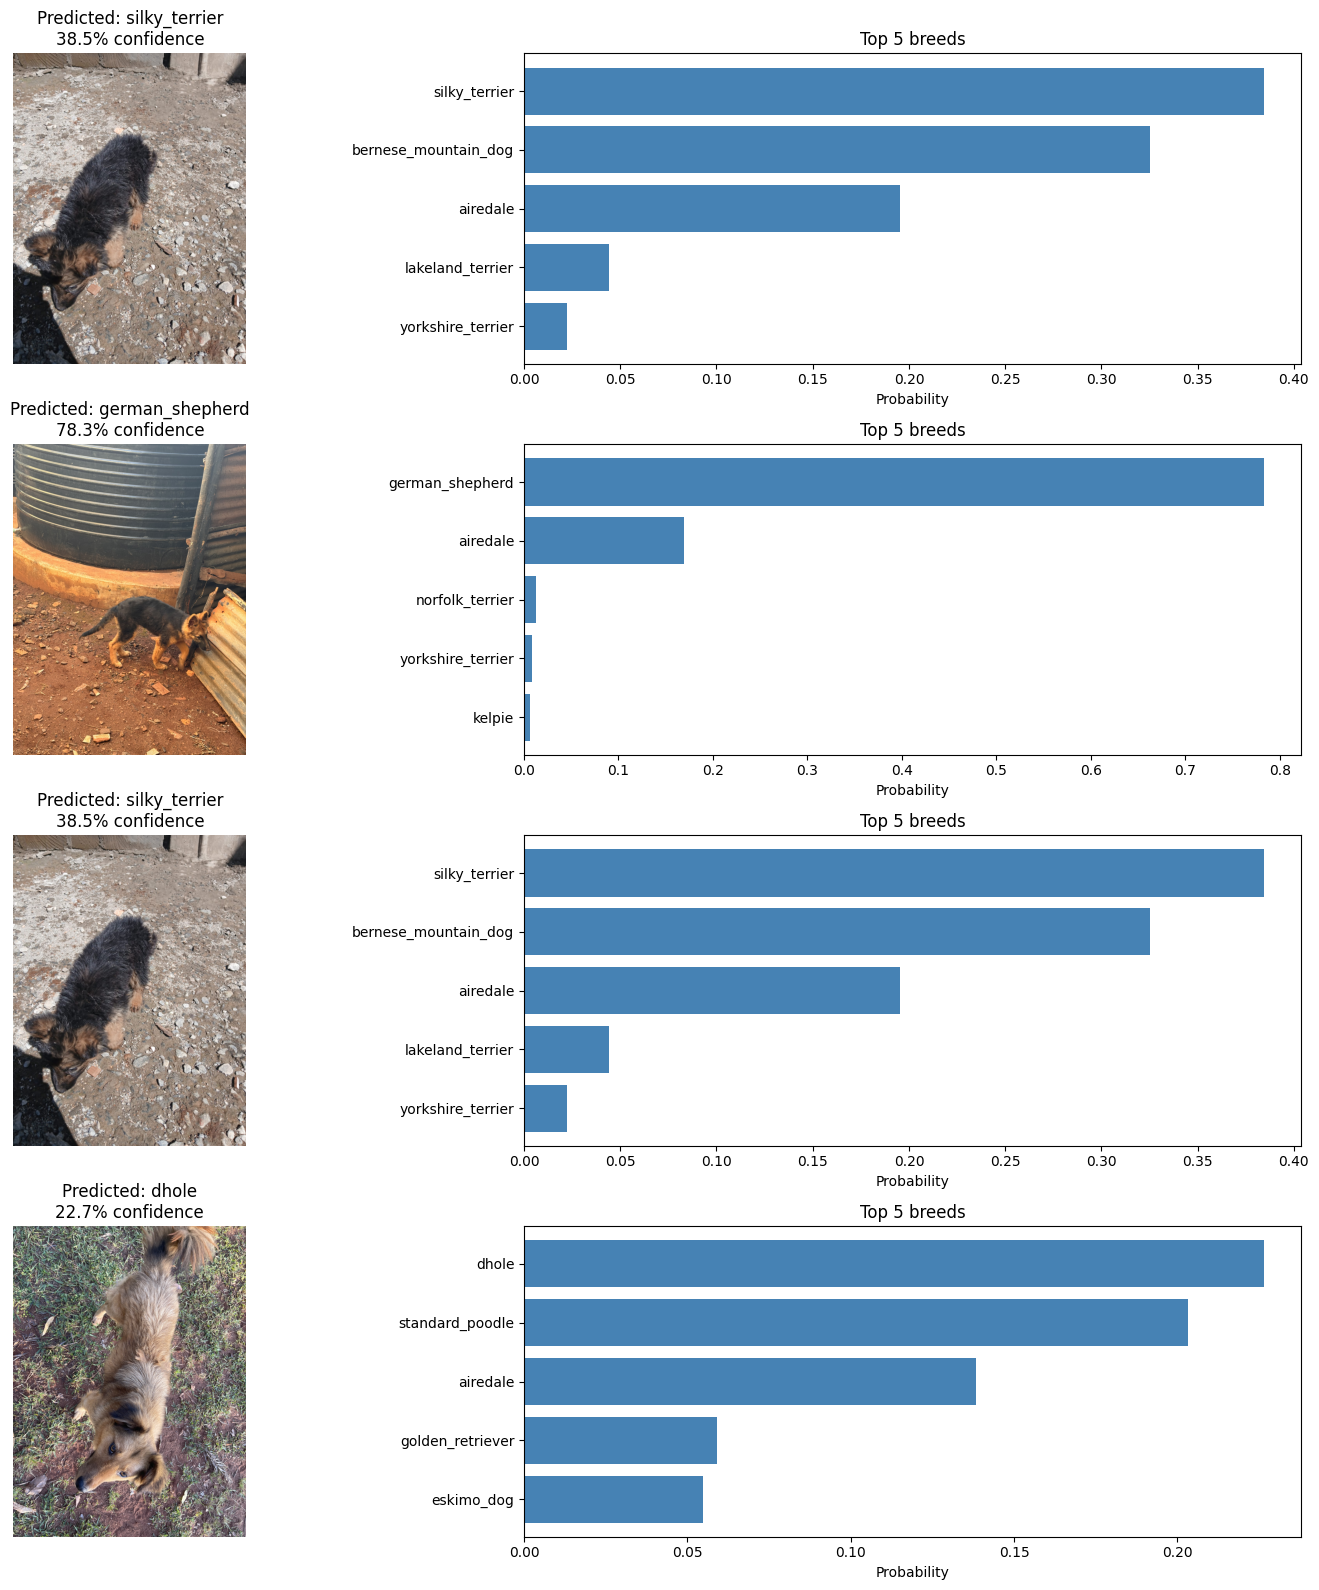

In [89]:
# Visualize predictions for each of my dog images
plt.figure(figsize=(16, 4 * len(my_dog_filenames)))
for i, (filepath, pred) in enumerate(zip(my_dog_filenames, my_dog_predictions)):
    # Load and display the image
    ax = plt.subplot(len(my_dog_filenames), 2, 2 * i + 1)
    img = plt.imread(filepath)
    plt.imshow(img)
    plt.axis("off")
    pred_label = get_pred_label(pred)
    confidence = np.max(pred) * 100
    plt.title(f"Predicted: {pred_label}\n{confidence:.1f}% confidence", fontsize=12)

    # Show top 5 breed probabilities
    ax2 = plt.subplot(len(my_dog_filenames), 2, 2 * i + 2)
    top5_idx = pred.argsort()[-5:][::-1]
    plt.barh(unique_breeds[top5_idx][::-1], pred[top5_idx][::-1], color="steelblue")
    plt.xlabel("Probability")
    plt.title("Top 5 breeds")

plt.tight_layout()
plt.show()
